# Setting × passage abstractness — Path A

Quick analysis of existing PassageContentTask annotations (gemini-2.5-flash, 1,051 passages across 212 texts) joined to passage abstractness scores. Two questions:

1. **Which setting categories cluster abstract vs concrete?** (domestic_interior, urban_street, wilderness, etc.)
2. **Within-setting trajectories** — does each setting concretize across centuries, paralleling the within-subgenre/archetype/class findings from nb 17 and 18?

Path B (specificity field, scaled qwen on CSD3) is in progress with lltm-claude. This notebook validates the proposition before scaling.

In [1]:
import os
import pandas as pd
import numpy as np
import plotnine as p9
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm

plt.rcParams['figure.dpi'] = 110
DROPBOX_FIGS = os.path.expanduser('~/Dropbox/Prof/Books/AbsLitHist/book/figures')
DROPBOX_DATA = os.path.expanduser('~/Dropbox/Prof/Books/AbsLitHist/data/llm_annotations')

df = pd.read_csv(os.path.join(DROPBOX_DATA, 'passage_annotations_scored.csv'))
df = df[df['setting'].notna() & df['conc_score'].notna() & df['meta_year'].notna()].copy()
df['year'] = df['meta_year'].astype(int)
df['century'] = (df['year'] // 100 * 100).astype(int)
df['abs_score'] = -df['conc_score']  # + = abstract
print(f'Passages with setting + abs_score + year: {len(df):,}')
print(f'Texts: {df["meta__id"].nunique():,}')
print(f'Year range: {df["year"].min()}-{df["year"].max()}')
print(f'\nCentury distribution:')
print(df.groupby('century').size().to_string())
print(f'\nSetting distribution:')
print(df['setting'].value_counts().to_string())

Passages with setting + abs_score + year: 1,051
Texts: 212
Year range: 1593-1903

Century distribution:
century
1500      8
1600    201
1700    449
1800    388
1900      5

Setting distribution:
setting
domestic_interior       460
abstract_unspecified    195
public_interior         103
wilderness               75
garden_grounds           51
rural_road               48
urban_street             45
ship_voyage              23
court_palace             23
battlefield              11
other                    11
mixed                     5
travel_movement           1


## 1. Setting × abstractness ranking

Mean passage abstractness per setting category. Tests whether spatial categories already encode abstract/concrete register before any specificity tagging.

Setting × mean abstractness (n>=20):
             setting   n  mean_abs    se
abstract_unspecified 195     0.527 0.047
   domestic_interior 460     0.435 0.027
     public_interior 103     0.399 0.059
      garden_grounds  51     0.345 0.080
          wilderness  75     0.338 0.066
        court_palace  23     0.326 0.148
          rural_road  48     0.241 0.099
        urban_street  45     0.216 0.079
         ship_voyage  23     0.152 0.128



Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/setting_abstractness_ranking.png


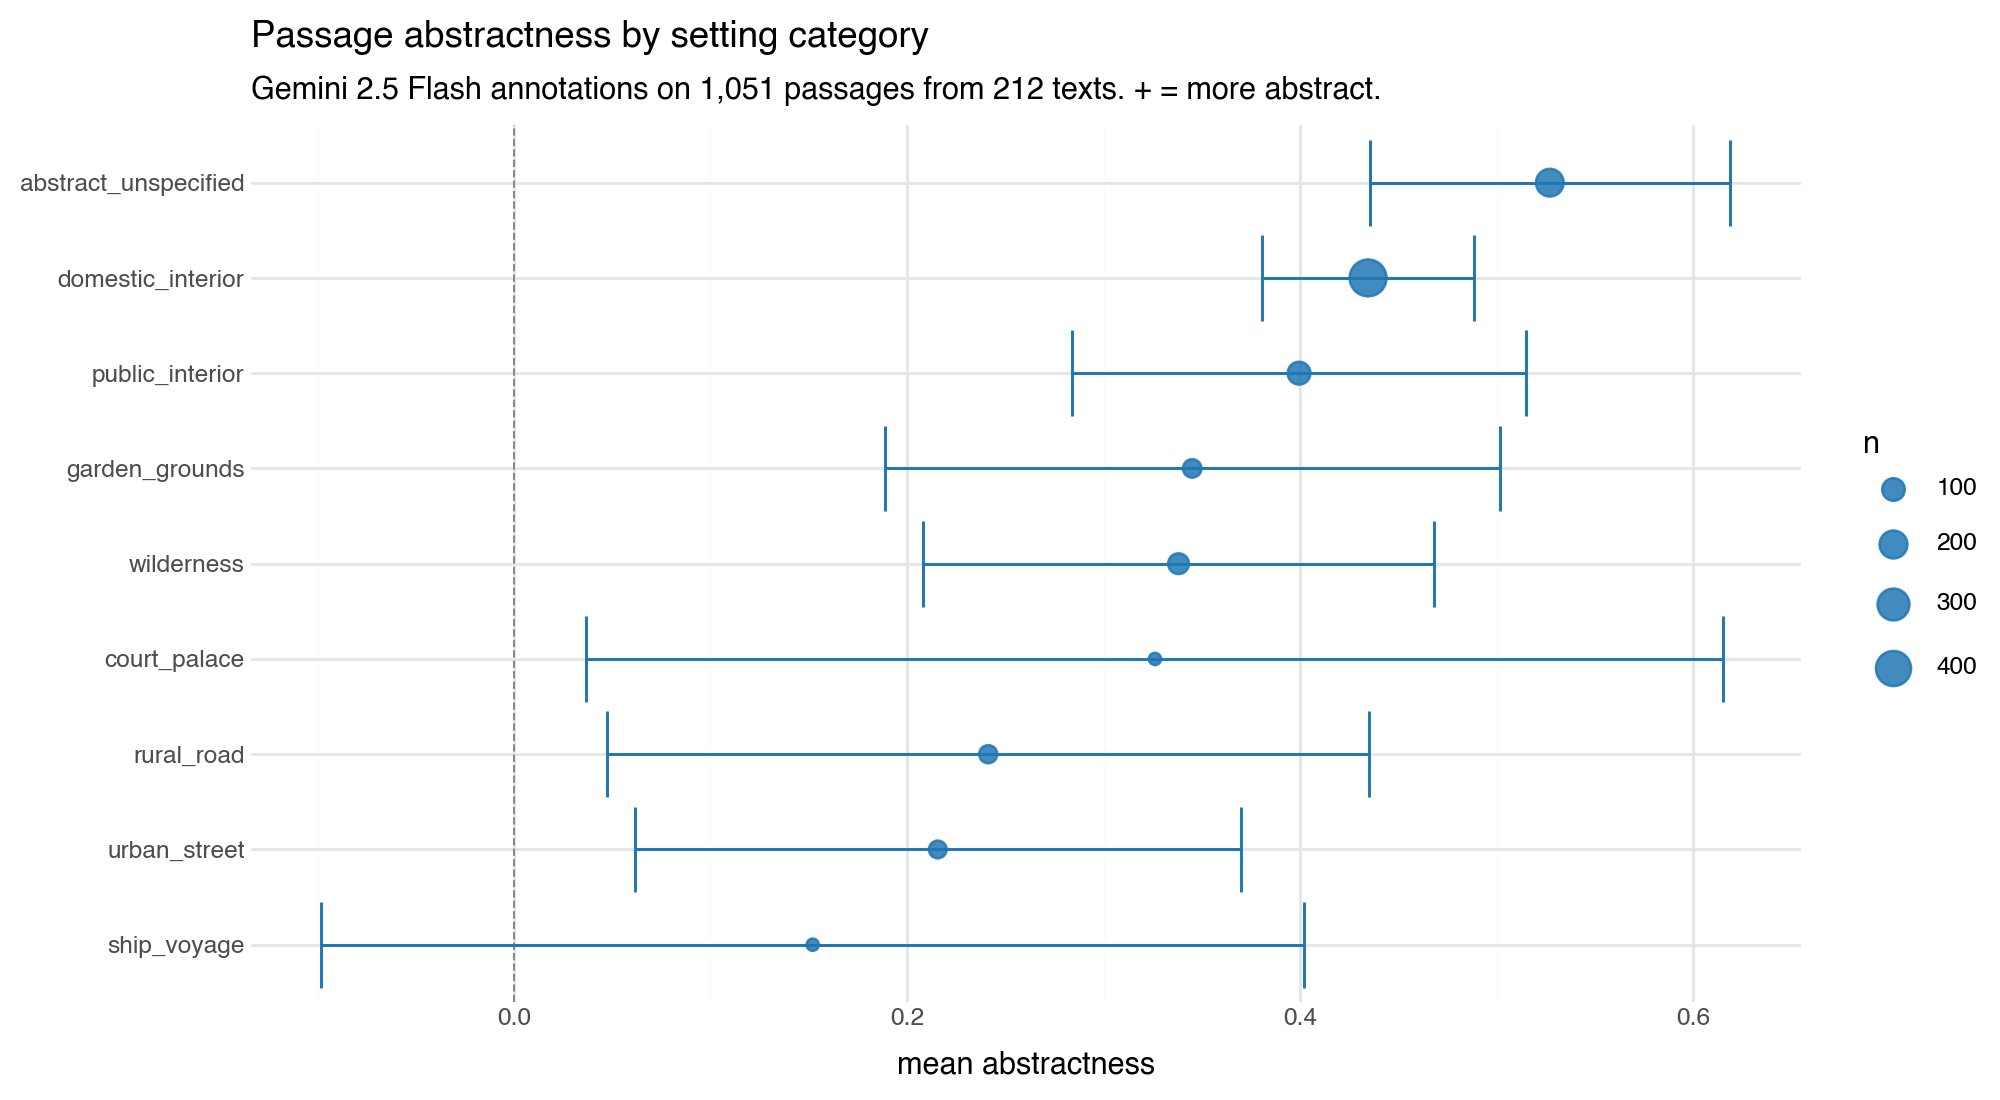

In [2]:
# Filter settings with n>=20 to keep the ranking stable
MIN_N = 20
stats = (df.groupby('setting')
         .agg(n=('abs_score', 'count'),
              mean_abs=('abs_score', 'mean'),
              se=('abs_score', 'sem'))
         .reset_index())
stats = stats[stats['n'] >= MIN_N].copy()
stats['lo'] = stats['mean_abs'] - 1.96 * stats['se']
stats['hi'] = stats['mean_abs'] + 1.96 * stats['se']
stats = stats.sort_values('mean_abs', ascending=False)

print('Setting × mean abstractness (n>=20):')
print(stats[['setting', 'n', 'mean_abs', 'se']].to_string(index=False, float_format='%.3f'))

stats['setting'] = pd.Categorical(stats['setting'],
                                   categories=stats.sort_values('mean_abs')['setting'].tolist(),
                                   ordered=True)

p_q1 = (p9.ggplot(stats, p9.aes(x='mean_abs', y='setting'))
        + p9.geom_vline(xintercept=0, color='#888888', linetype='dashed', size=0.4)
        + p9.geom_errorbarh(p9.aes(xmin='lo', xmax='hi'), height=0.0, size=0.6, color='#1f77b4')
        + p9.geom_point(p9.aes(size='n'), color='#1f77b4', alpha=0.85)
        + p9.scale_size_continuous(range=(2.0, 7.0))
        + p9.labs(
            title='Passage abstractness by setting category',
            subtitle=f'Gemini 2.5 Flash annotations on {len(df):,} passages from {df["meta__id"].nunique():,} texts. + = more abstract.',
            x='mean abstractness', y='', size='n',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(10, 5.5), legend_position='right'))
out = os.path.join(DROPBOX_FIGS, 'setting_abstractness_ranking.png')
p_q1.save(out, dpi=300, verbose=False)
print(f'\nSaved to {out}')
p_q1

## 2. Within-setting trajectories across centuries

Does each setting category concretize across centuries — paralleling the within-subgenre (§13), within-archetype (P3), within-class (P5) findings? Two views: absolute mean and deviation-from-period-baseline.

Settings with n>=10 in 3+ centuries: 5 -> ['abstract_unspecified', 'domestic_interior', 'public_interior', 'urban_street', 'wilderness']

Period abstractness baseline:
century
1500    0.276
1600    0.539
1700    0.516
1800    0.225
1900    0.364



Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/setting_abstractness_century_trajectory.png
Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/setting_abstractness_century_deviation.png

Mean abstractness by setting × century:
century                 C17    C18    C19
setting                                  
abstract_unspecified  0.621  0.681  0.170
public_interior       0.588  0.410  0.288
domestic_interior     0.528  0.538  0.265
wilderness            0.454  0.534  0.207
urban_street          0.334  0.083  0.246

Deviation from period baseline:
century                 C17    C18    C19
setting                                  
abstract_unspecified  0.082  0.165 -0.055
public_interior       0.049 -0.106  0.063
domestic_interior    -0.011  0.022  0.041
wilderness           -0.085  0.018 -0.018
urban_street         -0.205 -0.432  0.022


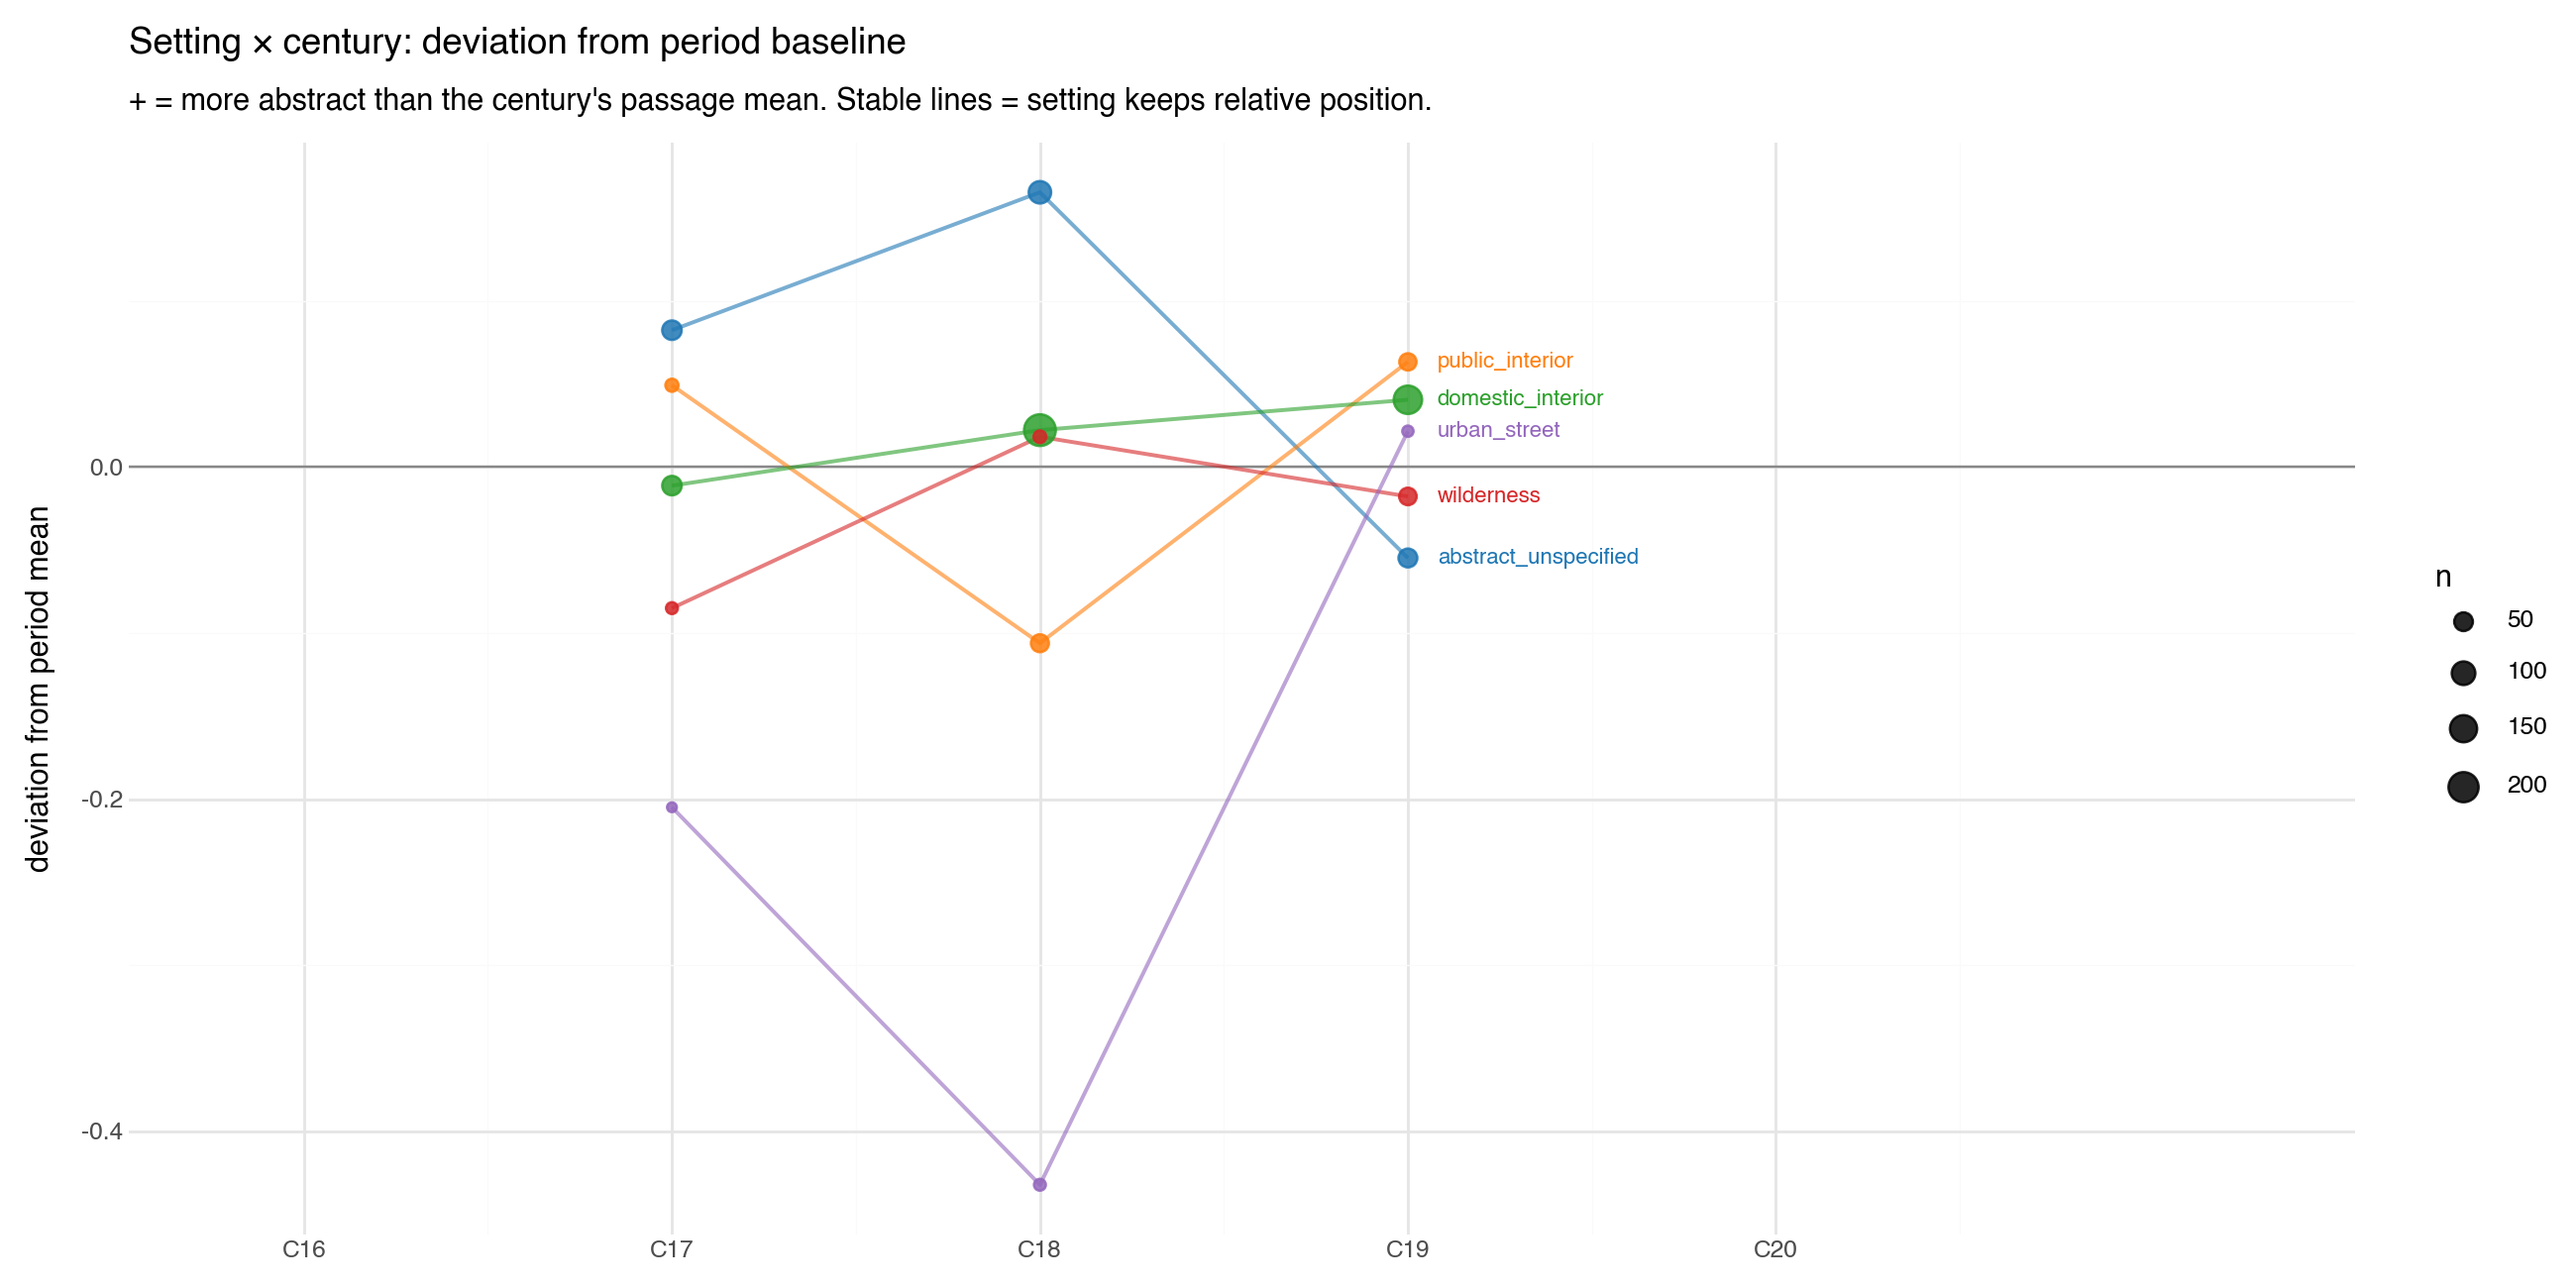

In [3]:
# Per (setting, century) cells
rows = []
for setting in df['setting'].unique():
    for cent in (1500, 1600, 1700, 1800, 1900):
        sub = df[(df['setting'] == setting) & (df['century'] == cent)]
        if len(sub) >= 10:
            rows.append({
                'setting': setting, 'century_year': cent + 50,
                'century': f'C{cent//100+1}',
                'n': len(sub),
                'mean_abs': sub['abs_score'].mean(),
                'se': sub['abs_score'].sem(),
            })
tdf = pd.DataFrame(rows)
n_cents = tdf.groupby('setting')['century_year'].nunique()
multi = n_cents[n_cents >= 3].index.tolist()
tdf = tdf[tdf['setting'].isin(multi)].copy()
print(f'Settings with n>=10 in 3+ centuries: {len(multi)} -> {sorted(multi)}')

# Period baseline
period_mean = df.groupby('century')['abs_score'].mean()
print(f'\nPeriod abstractness baseline:')
print(period_mean.round(3).to_string())
tdf['baseline'] = tdf['century_year'].map(lambda y: period_mean.loc[y - 50])
tdf['dev'] = tdf['mean_abs'] - tdf['baseline']

# Order by C18 mean abstractness (or earliest if missing)
anchor = tdf.groupby('setting')['mean_abs'].first().reindex(multi)
set_order = anchor.sort_values(ascending=False).index.tolist()
tab10_h = [mcolors.to_hex(c) for c in mcm.tab10.colors]
set_pal = dict(zip(set_order, tab10_h[:len(set_order)]))
tdf['setting'] = pd.Categorical(tdf['setting'], categories=set_order, ordered=True)
labels = tdf.sort_values('century_year').groupby('setting', observed=True, as_index=False).last()

# Absolute trajectories
p_abs = (p9.ggplot(tdf, p9.aes(x='century_year', y='mean_abs',
                                group='setting', color='setting'))
         + p9.geom_hline(yintercept=0, color='#888888', linetype='dashed', size=0.4)
         + p9.geom_line(size=0.8, alpha=0.6)
         + p9.geom_point(p9.aes(size='n'), alpha=0.85)
         + p9.scale_size_continuous(range=(1.5, 6.0))
         + p9.geom_text(p9.aes(label='setting'), data=labels,
                        nudge_x=8, ha='left', size=8, fontweight='bold',
                        show_legend=False)
         + p9.scale_color_manual(values=set_pal, guide=None)
         + p9.scale_x_continuous(breaks=[1550,1650,1750,1850,1950],
                                 labels=['C16','C17','C18','C19','C20'],
                                 limits=(1530, 2080))
         + p9.labs(
             title='Setting × century: mean passage abstractness',
             subtitle='Absolute trajectories; lines show within-setting concretization across centuries.',
             x='', y='mean abstractness', size='n',
         )
         + p9.theme_minimal()
         + p9.theme(figure_size=(13, 6.5), legend_position='right'))
out_abs = os.path.join(DROPBOX_FIGS, 'setting_abstractness_century_trajectory.png')
p_abs.save(out_abs, dpi=300, verbose=False)
print(f'\nSaved to {out_abs}')

# Deviation trajectories
p_dev = (p9.ggplot(tdf, p9.aes(x='century_year', y='dev',
                                group='setting', color='setting'))
         + p9.geom_hline(yintercept=0, color='#888888', size=0.5)
         + p9.geom_line(size=0.8, alpha=0.6)
         + p9.geom_point(p9.aes(size='n'), alpha=0.85)
         + p9.scale_size_continuous(range=(1.5, 6.0))
         + p9.geom_text(p9.aes(label='setting'), data=labels,
                        nudge_x=8, ha='left', size=8, fontweight='bold',
                        show_legend=False)
         + p9.scale_color_manual(values=set_pal, guide=None)
         + p9.scale_x_continuous(breaks=[1550,1650,1750,1850,1950],
                                 labels=['C16','C17','C18','C19','C20'],
                                 limits=(1530, 2080))
         + p9.labs(
             title='Setting × century: deviation from period baseline',
             subtitle='+ = more abstract than the century\'s passage mean. Stable lines = setting keeps relative position.',
             x='', y='deviation from period mean', size='n',
         )
         + p9.theme_minimal()
         + p9.theme(figure_size=(13, 6.5), legend_position='right'))
out_dev = os.path.join(DROPBOX_FIGS, 'setting_abstractness_century_deviation.png')
p_dev.save(out_dev, dpi=300, verbose=False)
print(f'Saved to {out_dev}')

# Print table
tbl = tdf.pivot(index='setting', columns='century', values='mean_abs').round(3)
tbl = tbl.reindex(set_order)
print('\nMean abstractness by setting × century:')
print(tbl.to_string())

tbl_d = tdf.pivot(index='setting', columns='century', values='dev').round(3)
tbl_d = tbl_d.reindex(set_order)
print('\nDeviation from period baseline:')
print(tbl_d.to_string())

p_dev

# Path B — passage-level setting specificity

Local-LLM (qwen36-27b) annotations on a decile sample (10 fixed-position passages per text) of arc_fiction. Loaded from `lltk.passage_annotations`. Each passage gets:

- `setting` (multi-label, ~70 categories): city_street, country_house, bedchamber, palace, ...
- `setting_specificity`: generic / typed / named / fully_described — the **Ch5 headline axis**
- `time_specificity`: same scale, applied to time
- `narrative_frequency`: singulative / iterative / repeating
- `space_traversed`: room / building / city / region / world
- `time_elapsed`: minutes / hours / days / months / years

Joined to passage-level lexical abstractness via `abstraction.passage_scores` (scheme='p500', column `Abs-Conc.Median.median`, + = concrete).

**Caveat (current run, 2026-04-28):** vast.ai still streaming; current N=296 texts (target 1,455), all chadwyck, alphabetical ordering means C19 `ncf*` and early-C18 are present but not full corpus. Rerun all cells when full drop lands.

In [ ]:
import clickhouse_connect
import numpy as np
import pandas as pd
import plotnine as p9
import matplotlib.colors as mcolors
import matplotlib.cm as mcm

ch = clickhouse_connect.get_client(host='localhost', port=8123, username='lltk', password='lltk')

LOAD_Q = """
WITH ann_wide AS (
  SELECT _id, seq, max(position) AS position,
    anyIf(value, field='setting_specificity') AS setting_specificity,
    anyIf(value, field='time_specificity')    AS time_specificity,
    anyIf(value, field='narrative_frequency') AS narrative_frequency,
    anyIf(value, field='time_elapsed')        AS time_elapsed,
    anyIf(value, field='space_traversed')     AS space_traversed,
    groupArrayIf(value, field='setting')      AS settings
  FROM lltk.passage_annotations
  GROUP BY _id, seq
)
SELECT
  ann._id AS text_id, ann.seq AS seq, ann.position AS position,
  ann.setting_specificity, ann.time_specificity,
  ann.narrative_frequency, ann.time_elapsed, ann.space_traversed,
  ann.settings,
  ps.scores['Abs-Conc.Median.median'] AS abs_score,
  toInt32OrNull(toString(t.year)) AS year,
  t.corpus AS corpus
FROM ann_wide ann
LEFT JOIN (
  SELECT _id, seq, scores FROM abstraction.passage_scores
  WHERE scheme='p500' AND lang='en'
) ps ON ann._id = ps._id AND ann.seq = ps.seq
LEFT JOIN lltk.texts t ON ann._id = t._id
"""

pdf = ch.query_df(LOAD_Q)

# Ordinal scales (canonical from PassageSettingTask schema, via lltm-claude 2026-04-28)
SPEC_ORDER = ['generic', 'typed', 'named', 'fully_described']
SPEC_ORD = {v: i for i, v in enumerate(SPEC_ORDER)}

SPACE_ORDER = ['none', 'room', 'building', 'grounds', 'neighborhood',
               'city', 'region', 'country', 'international']
SPACE_ORD = {v: i for i, v in enumerate(SPACE_ORDER)}

TIME_ORDER = ['moment', 'minutes', 'hours', 'day', 'days',
              'weeks', 'months', 'years', 'lifetime']
TIME_ORD = {v: i for i, v in enumerate(TIME_ORDER)}

pdf['spec_ord']      = pdf['setting_specificity'].map(SPEC_ORD).astype('Float32')
pdf['time_spec_ord'] = pdf['time_specificity'].map(SPEC_ORD).astype('Float32')
pdf['space_ord']     = pdf['space_traversed'].map(SPACE_ORD).astype('Float32')
pdf['time_ord']      = pdf['time_elapsed'].map(TIME_ORD).astype('Float32')
# Narrative tempo: positive = fast (more space per unit story time), negative = slow.
# Both axes are log-spaced ordinals so a difference is interpretable as a log ratio.
pdf['tempo']         = pdf['space_ord'] - pdf['time_ord']

# Drop passages with missing year for diachronic work
pdfy = pdf.dropna(subset=['year']).copy()
pdfy['year'] = pdfy['year'].astype(int)
pdfy['decade'] = (pdfy['year'] // 10 * 10).astype(int)
pdfy['century'] = (pdfy['year'] // 100 * 100).astype(int)

# Reverse lexical score so + = abstract (matches earlier in this nb)
pdfy['abs_score_neg'] = -pdfy['abs_score']

print(f'Passages: {len(pdf):,} ({len(pdfy):,} with year)')
print(f'Texts:    {pdf["text_id"].nunique():,} ({pdfy["text_id"].nunique():,} with year)')
print(f'Year:     {pdfy["year"].min()}-{pdfy["year"].max()}')
print()
print('setting_specificity distribution:')
print(pdf['setting_specificity'].value_counts().reindex(SPEC_ORDER).to_string())
print()
print('space_traversed distribution:')
print(pdf['space_traversed'].value_counts().reindex(SPACE_ORDER).to_string())
print()
print('time_elapsed distribution:')
print(pdf['time_elapsed'].value_counts().reindex(TIME_ORDER).to_string())
print()
print('Texts per decade:')
print(pdfy.groupby('decade')['text_id'].nunique().to_string())

## B1. Decade-level specificity curve (Ch5 headline)

Mean `setting_specificity` ordinal (generic=0, typed=1, named=2, fully_described=3) by decade. Tests whether settings get more *content-specific* over time — the LLM-content analogue of the lexical concretization arc.

Two views: (a) **mean ordinal** as a single curve, and (b) **mix** as a stacked area over time, so we can see whether change is at the named/fully_described top or the generic bottom.

In [ ]:
# Decade curve: pool only decades with at least MIN_PASSAGES annotated passages
MIN_PASSAGES = 30
dec = (pdfy.dropna(subset=['spec_ord'])
       .groupby('decade')
       .agg(n=('spec_ord', 'count'),
            n_texts=('text_id', 'nunique'),
            mean_spec=('spec_ord', 'mean'),
            se=('spec_ord', 'sem'),
            mean_abs=('abs_score_neg', 'mean'))
       .reset_index())
dec = dec[dec['n'] >= MIN_PASSAGES].copy()
# Cast away nullable / Float32 dtypes that confuse plotnine
for c in ['n', 'n_texts']:
    dec[c] = dec[c].astype(int)
for c in ['mean_spec', 'se', 'mean_abs']:
    dec[c] = dec[c].astype(float)
dec['lo'] = dec['mean_spec'] - 1.96 * dec['se']
dec['hi'] = dec['mean_spec'] + 1.96 * dec['se']

print(f'Decades with n >= {MIN_PASSAGES}:')
print(dec[['decade', 'n_texts', 'n', 'mean_spec', 'se', 'mean_abs']].round(3).to_string(index=False))

p_dec = (p9.ggplot(dec, p9.aes(x='decade', y='mean_spec'))
         + p9.geom_ribbon(p9.aes(ymin='lo', ymax='hi'), fill='#1f77b4', alpha=0.18)
         + p9.geom_line(color='#1f77b4', size=0.9)
         + p9.geom_point(p9.aes(size='n'), color='#1f77b4', alpha=0.85)
         + p9.scale_size_continuous(range=(2, 7))
         + p9.scale_x_continuous(breaks=list(range(1600, 1960, 50)))
         + p9.labs(title='Setting specificity by decade',
                   subtitle=f'+ = more specific (named/fully_described). N={int(dec["n"].sum()):,} passages from {pdfy["text_id"].nunique():,} texts.',
                   x='', y='mean specificity (0=generic, 3=fully_described)', size='n')
         + p9.theme_minimal()
         + p9.theme(figure_size=(11, 5)))
DROPBOX_FIGS = os.path.expanduser('~/Dropbox/Prof/Books/AbsLitHist/book/figures')
p_dec.save(os.path.join(DROPBOX_FIGS, 'pathB_specificity_decade.png'), dpi=300, verbose=False)
p_dec

In [ ]:
# Stacked-area: how the four levels mix shifts over time
mix = (pdfy.dropna(subset=['setting_specificity'])
       .groupby(['decade', 'setting_specificity'])
       .size().rename('n').reset_index())
totals = mix.groupby('decade')['n'].sum()
keep_decades = totals[totals >= MIN_PASSAGES].index
mix = mix[mix['decade'].isin(keep_decades)].copy()
mix['frac'] = mix.apply(lambda r: r['n'] / totals.loc[r['decade']], axis=1).astype(float)
mix['setting_specificity'] = pd.Categorical(mix['setting_specificity'], categories=SPEC_ORDER, ordered=True)

p_mix = (p9.ggplot(mix, p9.aes(x='decade', y='frac', fill='setting_specificity'))
         + p9.geom_area(alpha=0.85, position='stack')
         + p9.scale_fill_manual(values={'generic': '#a6cee3', 'typed': '#1f78b4',
                                        'named': '#b2df8a', 'fully_described': '#33a02c'})
         + p9.scale_x_continuous(breaks=list(range(1600, 1960, 50)))
         + p9.labs(title='Setting specificity mix by decade',
                   subtitle='Where the change happens: bottom = generic, top = fully_described.',
                   x='', y='proportion of passages')
         + p9.theme_minimal()
         + p9.theme(figure_size=(11, 5)))
p_mix.save(os.path.join(DROPBOX_FIGS, 'pathB_specificity_mix_decade.png'), dpi=300, verbose=False)
p_mix

## B2. Within-text position dynamics

Decile sample: each text contributes 10 passages at fixed positions (0.1, 0.2, ..., 1.0). Does setting specificity rise from beginning to end? Position 0.1 = openings (typically setup/exposition); position 1.0 = closings (potentially epilogue/wrap-up artifact, flag if outlier).

In [ ]:
# Within-text: aggregate by position decile
pdf_pos = pdf.dropna(subset=['spec_ord']).copy()
# Position is a Float32 in CH; round to nearest 0.1 to bucket cleanly
pdf_pos['pos_dec'] = (pdf_pos['position'] * 10).round().astype(int) / 10

pos = (pdf_pos.groupby('pos_dec')
       .agg(n=('spec_ord', 'count'),
            mean_spec=('spec_ord', 'mean'),
            se=('spec_ord', 'sem'),
            mean_abs=('abs_score', 'mean'))
       .reset_index())
pos['n'] = pos['n'].astype(int)
for c in ['mean_spec', 'se', 'mean_abs']:
    pos[c] = pos[c].astype(float)
pos['lo'] = pos['mean_spec'] - 1.96 * pos['se']
pos['hi'] = pos['mean_spec'] + 1.96 * pos['se']
pos['mean_abs_neg'] = -pos['mean_abs']  # + = abstract

print('Within-text position decile, mean specificity + abstractness:')
print(pos[['pos_dec', 'n', 'mean_spec', 'se', 'mean_abs_neg']].round(3).to_string(index=False))

p_pos = (p9.ggplot(pos, p9.aes(x='pos_dec', y='mean_spec'))
         + p9.geom_ribbon(p9.aes(ymin='lo', ymax='hi'), fill='#d62728', alpha=0.18)
         + p9.geom_line(color='#d62728', size=0.9)
         + p9.geom_point(p9.aes(size='n'), color='#d62728', alpha=0.85)
         + p9.scale_size_continuous(range=(2, 7))
         + p9.scale_x_continuous(breaks=[round(i * 0.1, 1) for i in range(1, 11)])
         + p9.labs(title='Setting specificity by within-text position',
                   subtitle='Each text contributes 10 passages at fixed deciles (0.1–1.0).',
                   x='within-text position (0.1 = first decile … 1.0 = last)',
                   y='mean specificity', size='n')
         + p9.theme_minimal()
         + p9.theme(figure_size=(10, 5)))
p_pos.save(os.path.join(DROPBOX_FIGS, 'pathB_specificity_position.png'), dpi=300, verbose=False)
p_pos

## B3. Specificity × abstractness correlation

Per-passage cross-tab: **lexical abstractness** (Word-norm score from `passage_scores`) by **content specificity** (LLM annotation). If the two scales agree at the passage level, generic/typed passages should score more abstract; named/fully_described should score more concrete. This is the validation that the two methods (lexical-statistical vs LLM-content) capture overlapping but non-redundant signal.

In [ ]:
# Specificity x abstractness
sub = pdf.dropna(subset=['spec_ord', 'abs_score']).copy()
sub['abs_score_neg'] = -sub['abs_score'].astype(float)  # + = abstract

corr = float(sub[['spec_ord', 'abs_score_neg']].corr().iloc[0, 1])
print(f'Pearson r(specificity, abstractness) = {corr:+.3f}  (expected: negative = more specific -> less abstract)')

stats = (sub.groupby('setting_specificity')
         .agg(n=('abs_score_neg', 'count'),
              mean=('abs_score_neg', 'mean'),
              se=('abs_score_neg', 'sem'))
         .reindex(SPEC_ORDER).reset_index())
stats['n'] = stats['n'].astype(int)
for c in ['mean', 'se']:
    stats[c] = stats[c].astype(float)
stats['lo'] = stats['mean'] - 1.96 * stats['se']
stats['hi'] = stats['mean'] + 1.96 * stats['se']
print()
print('Mean abstractness (+ = abstract) by specificity level:')
print(stats.round(3).to_string(index=False))

stats['setting_specificity'] = pd.Categorical(stats['setting_specificity'], categories=SPEC_ORDER, ordered=True)
p_corr = (p9.ggplot(stats, p9.aes(x='setting_specificity', y='mean'))
          + p9.geom_hline(yintercept=0, color='#888888', linetype='dashed')
          + p9.geom_errorbar(p9.aes(ymin='lo', ymax='hi'), width=0.0, color='#1f77b4')
          + p9.geom_point(p9.aes(size='n'), color='#1f77b4')
          + p9.scale_size_continuous(range=(3, 8))
          + p9.labs(title='Lexical abstractness by content specificity',
                    subtitle=f'Per-passage. r = {corr:+.3f}. + = lexically abstract.',
                    x='content specificity (LLM annotation)',
                    y='mean lexical abstractness', size='n')
          + p9.theme_minimal()
          + p9.theme(figure_size=(9, 5)))
p_corr.save(os.path.join(DROPBOX_FIGS, 'pathB_specificity_abstractness_corr.png'), dpi=300, verbose=False)
p_corr

## B4. Space traversed by decade

`space_traversed` ordinal: 0 none, 1 room, 2 building, 3 grounds, 4 neighborhood, 5 city, 6 region, 7 country (cross-country journey, not countryside), 8 international.

Tests whether the spatial scope of action zooms in (toward the room/building scale of domestic realism) or zooms out (toward travel/voyage) over time.

In [ ]:
# Decade trajectory of mean space_ord
MIN_PASSAGES = 30
sp_dec = (pdfy.dropna(subset=['space_ord'])
          .groupby('decade')
          .agg(n=('space_ord', 'count'),
               n_texts=('text_id', 'nunique'),
               mean_space=('space_ord', 'mean'),
               se=('space_ord', 'sem'))
          .reset_index())
sp_dec = sp_dec[sp_dec['n'] >= MIN_PASSAGES].copy()
for c in ['n', 'n_texts']: sp_dec[c] = sp_dec[c].astype(int)
for c in ['mean_space', 'se']: sp_dec[c] = sp_dec[c].astype(float)
sp_dec['lo'] = sp_dec['mean_space'] - 1.96 * sp_dec['se']
sp_dec['hi'] = sp_dec['mean_space'] + 1.96 * sp_dec['se']

print('Mean space_traversed by decade (0=none, 1=room, 2=building, 3=grounds, 4=neighborhood, 5=city, 6=region, 7=country, 8=international):')
print(sp_dec[['decade', 'n_texts', 'n', 'mean_space', 'se']].round(3).to_string(index=False))

p_sp = (p9.ggplot(sp_dec, p9.aes(x='decade', y='mean_space'))
        + p9.geom_ribbon(p9.aes(ymin='lo', ymax='hi'), fill='#2ca02c', alpha=0.18)
        + p9.geom_line(color='#2ca02c', size=0.9)
        + p9.geom_point(p9.aes(size='n'), color='#2ca02c', alpha=0.85)
        + p9.scale_size_continuous(range=(2, 7))
        + p9.scale_x_continuous(breaks=list(range(1600, 1960, 50)))
        + p9.scale_y_continuous(breaks=list(range(0, 9)),
                                labels=[f'{i} {SPACE_ORDER[i]}' for i in range(9)])
        + p9.labs(title='Spatial reach by decade',
                  subtitle='Mean space_traversed ordinal. Lower = action confined to room/building; higher = spans neighborhoods/cities/countries.',
                  x='', y='', size='n')
        + p9.theme_minimal()
        + p9.theme(figure_size=(11, 5)))
p_sp.save(os.path.join(DROPBOX_FIGS, 'pathB_space_decade.png'), dpi=300, verbose=False)
p_sp

## B5. Time elapsed by decade — narrative pace

`time_elapsed` ordinal: 0 moment, 1 minutes, 2 hours, 3 day (one specific day), 4 days (multiple), 5 weeks, 6 months, 7 years, 8 lifetime.

Since the discourse is a fixed ~500 tokens per passage, mean `time_elapsed` is **Genette's narrative pace**: low values = scene mode (real-time, dialogue, gesture); high values = summary mode (years pass in a paragraph).

In [ ]:
# Decade trajectory of mean time_ord (Genette's narrative pace)
te_dec = (pdfy.dropna(subset=['time_ord'])
          .groupby('decade')
          .agg(n=('time_ord', 'count'),
               n_texts=('text_id', 'nunique'),
               mean_time=('time_ord', 'mean'),
               se=('time_ord', 'sem'))
          .reset_index())
te_dec = te_dec[te_dec['n'] >= MIN_PASSAGES].copy()
for c in ['n', 'n_texts']: te_dec[c] = te_dec[c].astype(int)
for c in ['mean_time', 'se']: te_dec[c] = te_dec[c].astype(float)
te_dec['lo'] = te_dec['mean_time'] - 1.96 * te_dec['se']
te_dec['hi'] = te_dec['mean_time'] + 1.96 * te_dec['se']

print('Mean time_elapsed (narrative pace) by decade:')
print(te_dec[['decade', 'n_texts', 'n', 'mean_time', 'se']].round(3).to_string(index=False))

p_te = (p9.ggplot(te_dec, p9.aes(x='decade', y='mean_time'))
        + p9.geom_ribbon(p9.aes(ymin='lo', ymax='hi'), fill='#9467bd', alpha=0.18)
        + p9.geom_line(color='#9467bd', size=0.9)
        + p9.geom_point(p9.aes(size='n'), color='#9467bd', alpha=0.85)
        + p9.scale_size_continuous(range=(2, 7))
        + p9.scale_x_continuous(breaks=list(range(1600, 1960, 50)))
        + p9.scale_y_continuous(breaks=list(range(0, 9)),
                                labels=[f'{i} {TIME_ORDER[i]}' for i in range(9)])
        + p9.labs(title="Narrative pace by decade (Genette)",
                  subtitle='Mean time_elapsed ordinal. Lower = scene mode (real-time); higher = summary mode (years compressed).',
                  x='', y='', size='n')
        + p9.theme_minimal()
        + p9.theme(figure_size=(11, 5)))
p_te.save(os.path.join(DROPBOX_FIGS, 'pathB_time_decade.png'), dpi=300, verbose=False)
p_te

## B6. Story tempo — space per unit time

Tempo = `space_ord − time_ord`. Both axes are roughly log-spaced (each step ≈ ×5–10), so a difference is interpretable as a log ratio: how much spatial reach the passage covers per unit of story time. Positive = fast (travel summary, country-in-a-day); negative = slow (one room across hours).

Per lltm-claude's note: iterative passages ("he would often walk") behave differently from singulative summaries. Plot is also broken out by `narrative_frequency` for that reason.

In [ ]:
# Story tempo by decade, overall + by narrative_frequency
def tempo_by_decade(df, group=None):
    if group is not None:
        keys = ['decade', group]
    else:
        keys = ['decade']
    out = (df.dropna(subset=['tempo'])
           .groupby(keys)
           .agg(n=('tempo', 'count'),
                mean_tempo=('tempo', 'mean'),
                se=('tempo', 'sem'))
           .reset_index())
    out = out[out['n'] >= 30].copy()
    out['n'] = out['n'].astype(int)
    out['mean_tempo'] = out['mean_tempo'].astype(float)
    out['se'] = out['se'].astype(float)
    out['lo'] = out['mean_tempo'] - 1.96 * out['se']
    out['hi'] = out['mean_tempo'] + 1.96 * out['se']
    return out

tempo_dec = tempo_by_decade(pdfy)
print('Story tempo (space - time) by decade:')
print(tempo_dec[['decade', 'n', 'mean_tempo', 'se']].round(3).to_string(index=False))

p_tempo = (p9.ggplot(tempo_dec, p9.aes(x='decade', y='mean_tempo'))
           + p9.geom_hline(yintercept=0, color='#888888', linetype='dashed')
           + p9.geom_ribbon(p9.aes(ymin='lo', ymax='hi'), fill='#ff7f0e', alpha=0.18)
           + p9.geom_line(color='#ff7f0e', size=0.9)
           + p9.geom_point(p9.aes(size='n'), color='#ff7f0e', alpha=0.85)
           + p9.scale_size_continuous(range=(2, 7))
           + p9.scale_x_continuous(breaks=list(range(1600, 1960, 50)))
           + p9.labs(title='Story tempo by decade',
                     subtitle='Mean (space_ord - time_ord). + = fast (more space per unit story time); - = slow (lingering in one place).',
                     x='', y='space_ord - time_ord', size='n')
           + p9.theme_minimal()
           + p9.theme(figure_size=(11, 5)))
p_tempo.save(os.path.join(DROPBOX_FIGS, 'pathB_tempo_decade.png'), dpi=300, verbose=False)
p_tempo

In [ ]:
# Tempo broken out by narrative_frequency (singulative vs iterative vs other)
freq_dec = tempo_by_decade(pdfy, group='narrative_frequency')

# Keep the three biggest categories
top_freq = pdfy['narrative_frequency'].value_counts().nlargest(3).index.tolist()
freq_dec = freq_dec[freq_dec['narrative_frequency'].isin(top_freq)].copy()
print(f'narrative_frequency categories shown: {top_freq}')
print()
print('Tempo by decade x narrative_frequency:')
print(freq_dec.pivot(index='decade', columns='narrative_frequency', values='mean_tempo').round(3).to_string())

freq_pal = {'singulative': '#1f77b4', 'iterative': '#d62728', 'mixed': '#2ca02c',
            'repeating': '#9467bd', 'unspecified': '#7f7f7f'}
p_freq = (p9.ggplot(freq_dec, p9.aes(x='decade', y='mean_tempo',
                                      color='narrative_frequency',
                                      group='narrative_frequency'))
          + p9.geom_hline(yintercept=0, color='#888888', linetype='dashed')
          + p9.geom_line(size=0.8, alpha=0.85)
          + p9.geom_point(p9.aes(size='n'), alpha=0.85)
          + p9.scale_size_continuous(range=(2, 6))
          + p9.scale_color_manual(values=freq_pal)
          + p9.scale_x_continuous(breaks=list(range(1600, 1960, 50)))
          + p9.labs(title='Story tempo by decade × narrative frequency',
                    subtitle='Singulative = once-told event; iterative = habitual ("he would often..."); mixed = both.',
                    x='', y='space_ord - time_ord', color='', size='n')
          + p9.theme_minimal()
          + p9.theme(figure_size=(12, 5.5)))
p_freq.save(os.path.join(DROPBOX_FIGS, 'pathB_tempo_decade_byfreq.png'), dpi=300, verbose=False)
p_freq